In [19]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import networkx as nx
from pathlib import Path

from neural_reconstruction.core.topology import TopologyBuilder
from neural_reconstruction.core.pathfinding import PathFinder
from neural_reconstruction.algorithms.fragment_linking.utils import compute_vector_angle,is_direction_too_similar
from neural_reconstruction.core.preprocessing import dilate_epidermis_vertically
from neural_reconstruction.core.evaluation import (
    extract_graph_points,
    compute_average_hausdorff_distance,
    compute_point_min_distances,
    compute_cldice
)
import skimage as ski
# from skimage.measure import label
from scipy.spatial import KDTree
from sklearn.cluster import DBSCAN


In [20]:
BASE_PATH = Path('/home/pony/projects/ienf_q/data_0331')
IMAGE_ID = 'S1571-2_b'



In [21]:
image      = cv2.imread(f'{BASE_PATH}/{IMAGE_ID}/image.png',       cv2.IMREAD_COLOR_RGB)[:, :, 1]  # 只取綠色通道
mask       = cv2.imread(f'{BASE_PATH}/{IMAGE_ID}/mask.png',        cv2.IMREAD_GRAYSCALE)
annotation = cv2.imread(f'{BASE_PATH}/{IMAGE_ID}/weka.png',        cv2.IMREAD_GRAYSCALE)
label      = cv2.imread(f'{BASE_PATH}/{IMAGE_ID}/label.png',       cv2.IMREAD_GRAYSCALE)

In [22]:

roi_mask = dilate_epidermis_vertically(mask, offset_px=50)
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (51, 51))
background = cv2.morphologyEx(image, cv2.MORPH_OPEN, kernel)
image = cv2.subtract(image, background)

roi_image = cv2.bitwise_and(image, image, mask=roi_mask)
roi_annotation = cv2.bitwise_and(annotation, annotation, mask=roi_mask)

# apply opening to roi_annotation to remove small noise
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
# roi_annotation = cv2.morphologyEx(roi_annotation, cv2.MORPH_OPEN, kernel)

# apply closing to roi_annotation to fill small holes
roi_annotation = cv2.morphologyEx(roi_annotation, cv2.MORPH_CLOSE, kernel, iterations=3)
roi_annotation[roi_annotation > 0] = 255


gt_builder = TopologyBuilder()
roi_label = cv2.bitwise_and(label, label, mask=roi_mask)
roi_label = cv2.morphologyEx(roi_label, cv2.MORPH_CLOSE, kernel, iterations=3)
gt_graph = gt_builder.build_seed_graph(roi_label)


/home/pony/projects/ienf_q/src/neural_reconstruction/core/topology/topology_builder.py:125: VisibleDeprecationWarning: separator in column name will change to _ in version 0.13; to silence this warning, use `separator='-'` to maintain current behavior and use `separator='_'` to switch to the new default behavior.
  summary = summarize(skel_obj)


In [23]:
clahe = cv2.createCLAHE()
roi_image = clahe.apply(roi_image)

roi_image = ski.filters.sato(roi_image, sigmas=range(4, 8), black_ridges=False)
# min max roi image
roi_image = (roi_image - roi_image.min()) / (roi_image.max() - roi_image.min()) * 255
roi_image = roi_image.astype(np.uint8)

In [24]:
annotation_component = np.asarray(ski.measure.label(roi_annotation, connectivity=2))

# 2. 骨架化 + 種子切分
topology_builder = TopologyBuilder(segment_length=3.0)
seed_graph = topology_builder.build_seed_graph(roi_annotation, roi_image)

# 從 labeled image 補上 component_id
for node in seed_graph.nodes():
    y, x = node
    seed_graph.nodes[node]["component_id"] = int(annotation_component[int(y), int(x)])

# 元件內邊設低成本
for u, v, data in seed_graph.edges(data=True):
    data["weight"] = 1e-5
# 3. 元件間路徑查找
cost_map = ((255 - roi_image.astype(np.float64)) / 255) ** 2


In [25]:
path_finder = PathFinder(cost_map)
topology_points = np.array(list(seed_graph.nodes()))

# kdtree = KDTree(topology_points)
seed_map = np.zeros_like(cost_map, dtype=bool)
for p in topology_points:
    seed_map[p[0], p[1]] = True


# path_lookup = path_finder.find_paths_from_seeds(
#     topology_points=topology_points,
#     kdtree=kdtree,
#     search_radius=50,
#     seed_map=seed_map,
#     label_img=annotation_component,
# )

In [26]:
nodes = list(seed_graph.nodes())
node_positions = np.array([[y, x] for y, x in nodes])  # shape: (N, 2)

# DBSCAN clustering — tune eps and min_samples as needed
eps = 20          # max distance between two points to be in the same neighborhood
min_samples = 10   # min points to form a core point

dbscan = DBSCAN(eps=eps, min_samples=min_samples)
cluster_labels = dbscan.fit_predict(node_positions)  # -1 = noise

cluster_nodes = {}
# Assign cluster labels back to graph nodes
for node, cluster_id in zip(nodes, cluster_labels):
    seed_graph.nodes[node]["cluster_id"] = int(cluster_id)
    if cluster_id not in cluster_nodes:
        cluster_nodes[cluster_id] = []
    cluster_nodes[cluster_id].append(node)

n_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
n_noise    = np.sum(cluster_labels == -1)
print(f"Nodes: {len(nodes)}")
print(f"Clusters found: {n_clusters}")
print(f"Noise points:   {n_noise}")

Nodes: 4023
Clusters found: 110
Noise points:   426


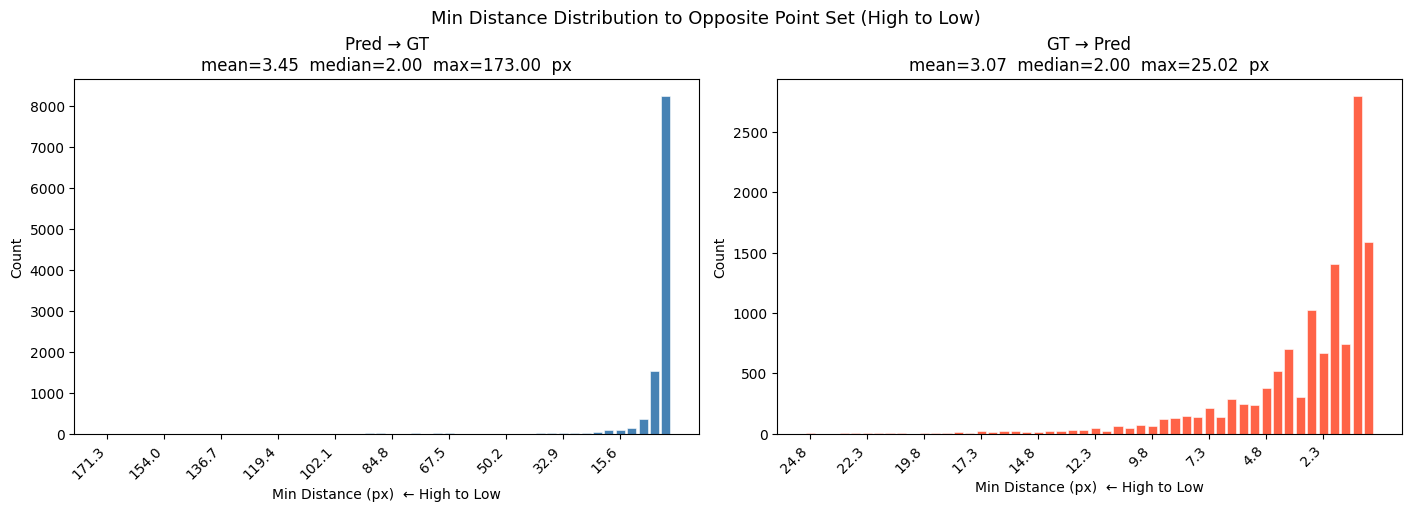

seed graph ClDice: 0.4597  TPrec: 0.6543  TSens: 0.3543


In [27]:
seed_points = extract_graph_points(seed_graph)
gt_points   = extract_graph_points(gt_graph)
min_pred_to_gt, min_gt_to_pred = compute_point_min_distances(seed_points, gt_points)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

BINS = 50

for ax, dists, label, color in [
    (axes[0], min_pred_to_gt, 'Pred → GT', 'steelblue'),
    (axes[1], min_gt_to_pred, 'GT → Pred', 'tomato'),
]:
    counts, edges = np.histogram(dists, bins=BINS)
    # Sort bins from high to low distance
    centers = (edges[:-1] + edges[1:]) / 2
    order   = np.argsort(centers)[::-1]
    ax.bar(range(BINS), counts[order], color=color, edgecolor='white', linewidth=0.4)
    ax.set_xticks(range(0, BINS, 5))
    ax.set_xticklabels([f'{centers[order][i]:.1f}' for i in range(0, BINS, 5)], rotation=45, ha='right')
    ax.set_xlabel('Min Distance (px)  ← High to Low')
    ax.set_ylabel('Count')
    ax.set_title(f'{label}\n'
                 f'mean={np.mean(dists):.2f}  median={np.median(dists):.2f}  '
                 f'max={np.max(dists):.2f}  px')

fig.suptitle('Min Distance Distribution to Opposite Point Set (High to Low)', fontsize=13)
plt.show()

cldice, tprec, tsens = compute_cldice(seed_graph, roi_label, tolerance_px=1)
print(f"seed graph ClDice: {cldice:.4f}  TPrec: {tprec:.4f}  TSens: {tsens:.4f}")

In [30]:
db_graph = nx.Graph()
for cluster_id, cluster_node in cluster_nodes.items():
    if cluster_id == -1:
        continue  # skip noise
    # print(f"Cluster {cluster_id}: {len(cluster_node)} nodes")
    cluster_graph = seed_graph.subgraph(cluster_node).copy()

    kdtree = KDTree(cluster_node)

    path_lookup = path_finder.find_paths_from_seeds(
        topology_points=cluster_node,
        kdtree=kdtree,
        search_radius=50,
        seed_map=seed_map,
        label_img=annotation_component,
    )

    for (u,v), (path,cost) in path_lookup.items():
        cluster_graph.add_edge(u, v, weight=cost, path=path)

    cluster_mst = nx.minimum_spanning_tree(cluster_graph, weight="weight")

    db_graph.add_edges_from(cluster_mst.edges(data=True))

for points in topology_points:
    if not db_graph.has_node(points):
        db_graph.add_node(tuple(points))
        
db_points = extract_graph_points(db_graph)

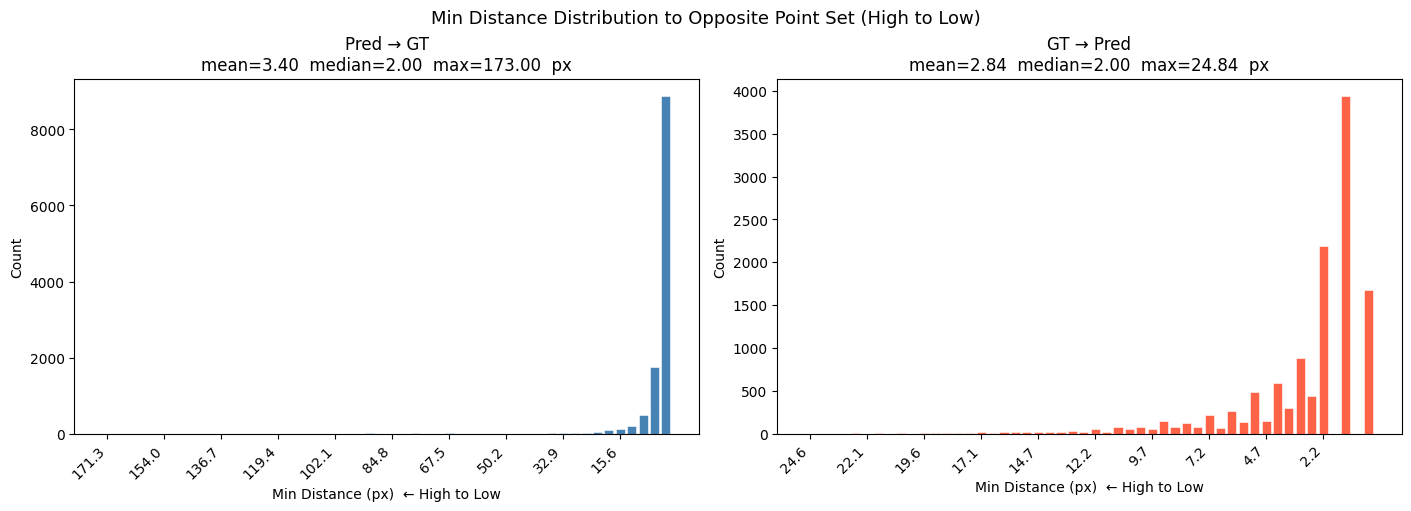

db graph ClDice: 0.4767  TPrec: 0.6397  TSens: 0.3799


In [31]:
min_pred_to_gt, min_gt_to_pred = compute_point_min_distances(db_points, gt_points)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

BINS = 50

for ax, dists, label, color in [
    (axes[0], min_pred_to_gt, 'Pred → GT', 'steelblue'),
    (axes[1], min_gt_to_pred, 'GT → Pred', 'tomato'),
]:
    counts, edges = np.histogram(dists, bins=BINS)
    # Sort bins from high to low distance
    centers = (edges[:-1] + edges[1:]) / 2
    order   = np.argsort(centers)[::-1]
    ax.bar(range(BINS), counts[order], color=color, edgecolor='white', linewidth=0.4)
    ax.set_xticks(range(0, BINS, 5))
    ax.set_xticklabels([f'{centers[order][i]:.1f}' for i in range(0, BINS, 5)], rotation=45, ha='right')
    ax.set_xlabel('Min Distance (px)  ← High to Low')
    ax.set_ylabel('Count')
    ax.set_title(f'{label}\n'
                 f'mean={np.mean(dists):.2f}  median={np.median(dists):.2f}  '
                 f'max={np.max(dists):.2f}  px')

fig.suptitle('Min Distance Distribution to Opposite Point Set (High to Low)', fontsize=13)
plt.show()

cldice, tprec, tsens = compute_cldice(db_graph, roi_label, tolerance_px=1)
print(f"db graph ClDice: {cldice:.4f}  TPrec: {tprec:.4f}  TSens: {tsens:.4f}")

In [32]:
fig, axes = plt.subplots(1, 1, figsize=(128, 64), constrained_layout=True)

def draw_mst_on_ax(ax, background, mst_forest, edge_color='lime', node_color='cyan',
                   linewidth=1, node_size=1.2, show_nodes=True):
    ax.imshow(background, cmap='gray' if background.ndim == 2 else None)
    for u, v, data in mst_forest.edges(data=True):
        path = data.get('path', [u, v])
        if len(path) < 2:
            continue
        ax.plot([p[1] for p in path], [p[0] for p in path],
                color=edge_color, linewidth=linewidth, alpha=0.85)
    if show_nodes:
        for node in mst_forest.nodes():
            is_endpoint = mst_forest.degree[node] == 1
            color = 'yellow' if is_endpoint else node_color
            ax.plot(node[1], node[0], '.', color=color, markersize=node_size)

draw_mst_on_ax(axes, roi_image, gt_graph, edge_color='red', node_color='magenta', linewidth=3, node_size=1, show_nodes=False)
draw_mst_on_ax(axes, roi_image, db_graph,linewidth=2, node_size=2, show_nodes=True)

axes.axis('off')
plt.savefig('db_graph.png')
plt.close(fig)
# plt.show()

In [13]:
extend_graph = db_graph.copy()
endpoints = [node for node in extend_graph.nodes() if extend_graph.degree(node) == 1]
print(f"Found {len(endpoints)} endpoints in DBSCAN graph")

RADIUS = 30
global_kdtree = KDTree(topology_points)
endpoint_kdtree = KDTree(endpoints)
for endpoint in endpoints:
    neighbors = list(extend_graph.neighbors(endpoint))
    if len(neighbors) != 1:
        continue

    neighbor = neighbors[0]
    extend_vector = np.array(endpoint) - np.array(neighbor)

    endpoint_arr = np.array(endpoint)
    candidate_indices = endpoint_kdtree.query_ball_point(endpoint_arr, r=RADIUS)
    candidate_nodes = [tuple(endpoints[idx]) for idx in candidate_indices]
    # print(f"Endpoint {endpoint} has {len(candidate_nodes)} candidate nodes within radius {RADIUS}")

    candidate_kdtree = KDTree(candidate_nodes)

    paths = path_finder.find_paths_from_seeds(
        topology_points=np.array(endpoints),
        kdtree=endpoint_kdtree,
        search_radius=RADIUS,
        seed_map=seed_map,
        label_img=annotation_component,
    )
    # print(f"Endpoint {endpoint} has {len(paths)} candidate paths to evaluate")

    for (u, v), (path, base_cost) in paths.items():
        
        if u!= endpoint and v != endpoint:
            continue
        target = v if u == endpoint else u
        if target == neighbor:
            continue
        if extend_graph.has_edge(endpoint, target):
            continue
        if seed_graph.nodes[endpoint]["cluster_id"] == seed_graph.nodes[target]["cluster_id"]:
            continue
        
        ac_vector = np.array(target) - endpoint_arr
        distance = np.linalg.norm(ac_vector)
        angle = compute_vector_angle(extend_vector, ac_vector)

        path_arr = np.array(path)
        diffs = np.diff(path_arr, axis=0)
        segment_dists = np.linalg.norm(diffs, axis=1)
        path_length = np.sum(segment_dists)

        # 計算最終成本
        distance_penalty = distance / RADIUS * 0.25  # distance penalty weight
        angle_penalty = angle / 180.0 * 0.25  # angle penalty weight

        final_cost = 0.5 * base_cost +  angle_penalty + distance_penalty
        # print(f"Evaluating path from {endpoint} to {target} with base cost {final_cost:.4f}")

        # if final_cost > path_length:
        #     continue
    
        extend_graph.add_edge(endpoint, target, weight=final_cost, path=path, base_cost=base_cost)
extend_graph = nx.minimum_spanning_tree(extend_graph, weight="weight")

Found 371 endpoints in DBSCAN graph


In [14]:
new_edge_count = extend_graph.number_of_edges() - db_graph.number_of_edges()
print(f"Added {new_edge_count} new edges in extended graph")

Added 30 new edges in extended graph


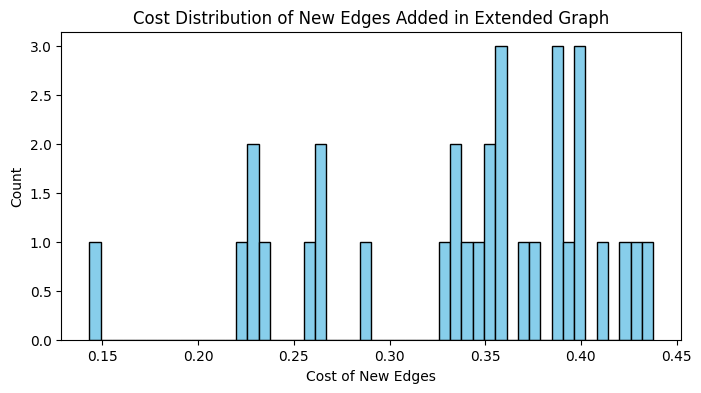

In [15]:
new_edges = set(extend_graph.edges()) - set(db_graph.edges())

# show new edges cost histogram
new_edge_costs = []
for edge in new_edges:
    path = extend_graph.edges[edge]['path']
    path_arr = np.array(path)
    diffs = np.diff(path_arr, axis=0)
    segment_dists = np.linalg.norm(diffs, axis=1)
    path_length = np.sum(segment_dists)
    new_edge_costs.append(extend_graph.edges[edge]['weight'] / path_length)


plt.figure(figsize=(8, 4))
plt.hist(new_edge_costs, bins=50, color='skyblue', edgecolor='black')
plt.xlabel('Cost of New Edges')
plt.ylabel('Count')
plt.title('Cost Distribution of New Edges Added in Extended Graph')
plt.show()

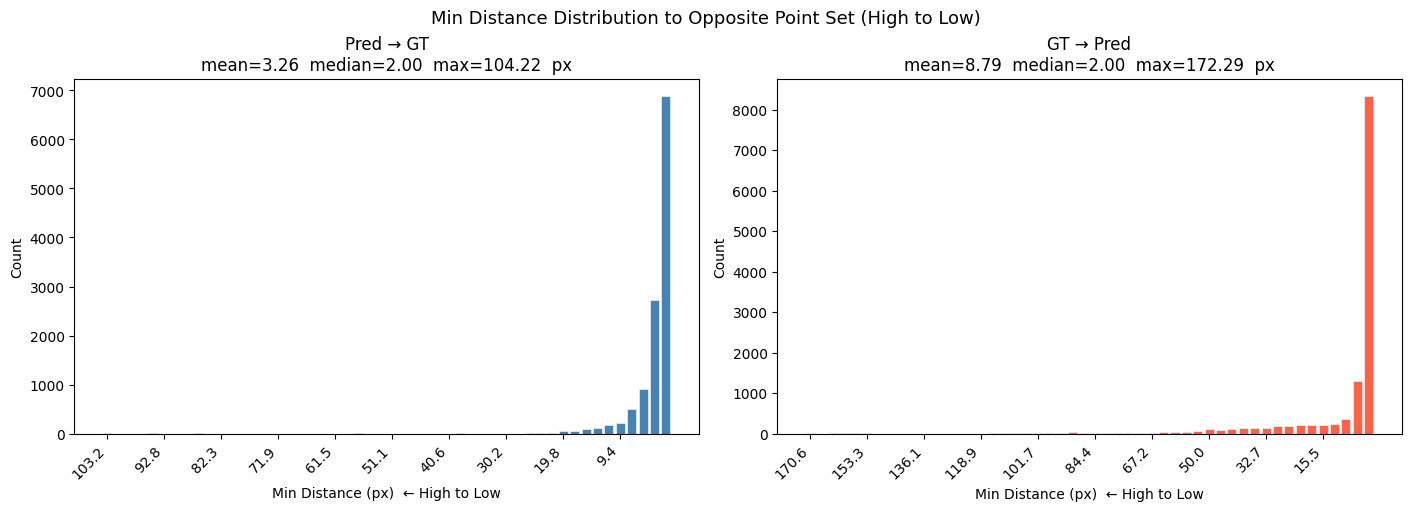

extend graph ClDice: 0.4659  TPrec: 0.6315  TSens: 0.3691


In [16]:
extend_points = extract_graph_points(extend_graph)
min_pred_to_gt, min_gt_to_pred = compute_point_min_distances(extend_points, gt_points)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

BINS = 50

for ax, dists, label, color in [
    (axes[0], min_pred_to_gt, 'Pred → GT', 'steelblue'),
    (axes[1], min_gt_to_pred, 'GT → Pred', 'tomato'),
]:
    counts, edges = np.histogram(dists, bins=BINS)
    # Sort bins from high to low distance
    centers = (edges[:-1] + edges[1:]) / 2
    order   = np.argsort(centers)[::-1]
    ax.bar(range(BINS), counts[order], color=color, edgecolor='white', linewidth=0.4)
    ax.set_xticks(range(0, BINS, 5))
    ax.set_xticklabels([f'{centers[order][i]:.1f}' for i in range(0, BINS, 5)], rotation=45, ha='right')
    ax.set_xlabel('Min Distance (px)  ← High to Low')
    ax.set_ylabel('Count')
    ax.set_title(f'{label}\n'
                 f'mean={np.mean(dists):.2f}  median={np.median(dists):.2f}  '
                 f'max={np.max(dists):.2f}  px')

fig.suptitle('Min Distance Distribution to Opposite Point Set (High to Low)', fontsize=13)
plt.show()

cldice, tprec, tsens = compute_cldice(extend_graph, roi_label, tolerance_px=1)
print(f"extend graph ClDice: {cldice:.4f}  TPrec: {tprec:.4f}  TSens: {tsens:.4f}")

In [18]:
fig, axes = plt.subplots(1, 1, figsize=(128, 64), constrained_layout=True)

draw_mst_on_ax(axes, roi_image, gt_graph, edge_color='red', node_color='magenta',
               linewidth=4, node_size=1, show_nodes=False)
draw_mst_on_ax(axes, roi_image, extend_graph,linewidth=2, node_size=5, show_nodes=False, )
draw_mst_on_ax(axes, roi_image, db_graph,linewidth=2, node_size=5, show_nodes=False, edge_color='cyan')


axes.axis('off')
plt.savefig('extend_graph.png')
plt.close(fig)
# plt.show()